In [3]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.Zheng2005 import Zheng2005

In [4]:
importlib.reload(Zheng2005)
Zheng2005.Table1().df

,ngbar,Model,numParams,logMmin,logM1,alpha,sigmalogM,M0,logM1prime
0,0.0200,SPH,3P,11.67,12.96,0.97,NaN,NaN,NaN
1,0.0200,SA,3P,11.77,12.96,1.04,NaN,NaN,NaN
2,0.0100,SPH,3P,12.04,13.26,1.03,NaN,NaN,NaN
3,0.0100,SA,3P,12.03,13.30,1.02,NaN,NaN,NaN
4,0.0050,SPH,3P,12.38,13.55,1.18,NaN,NaN,NaN
5,0.0050,SA,3P,12.34,13.64,1.09,NaN,NaN,NaN
6,0.0025,SPH,3P,12.68,13.85,1.24,NaN,NaN,NaN
7,0.0025,SA,3P,12.58,13.91,1.16,NaN,NaN,NaN
8,0.0200,SPH,5P,11.68,NaN,1.02,0.15,11.86,13.00
9,0.0200,SA,5P,11.73,NaN,0.96,0.32,12.09,12.87


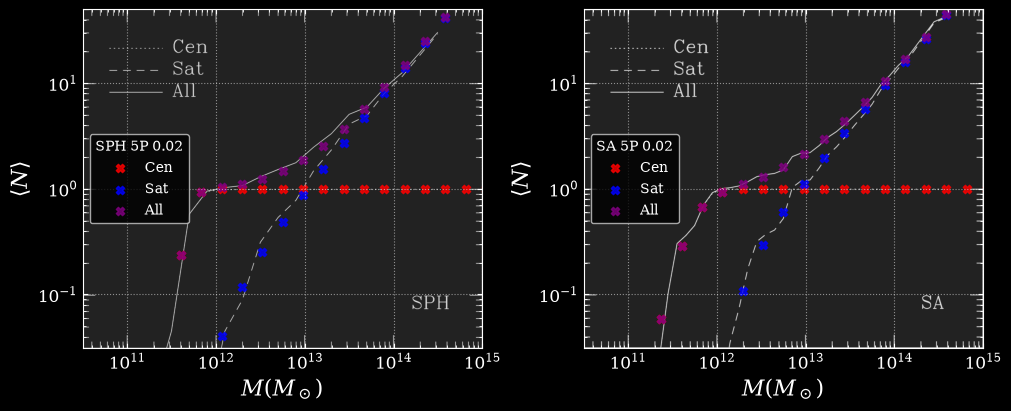

In [6]:
importlib.reload(Zheng2005)
fig, axs = Zheng2005.Fig1().full()

from Models import HODs
importlib.reload(HODs)

logMh = np.linspace(10, 15.5, 25)

for ax, model in zip(axs, ['SPH', 'SA']):
    Z05 = HODs.Zheng2005(model=model, nparams='5P', ng='0.02')
    ax.scatter(10**logMh, Z05.Ncen(logMh)(), marker='X', c='red', alpha=0.8, label='Cen')
    ax.scatter(10**logMh, Z05.Nsat(logMh)(), marker='X', c='blue', alpha=0.8, label='Sat')
    ax.scatter(10**logMh, Z05.Ntot(logMh)(), marker='X', alpha=0.8, c='purple', label='All')
    ax.legend(loc='center left', title=f'{model} 5P 0.02')

plt.show()

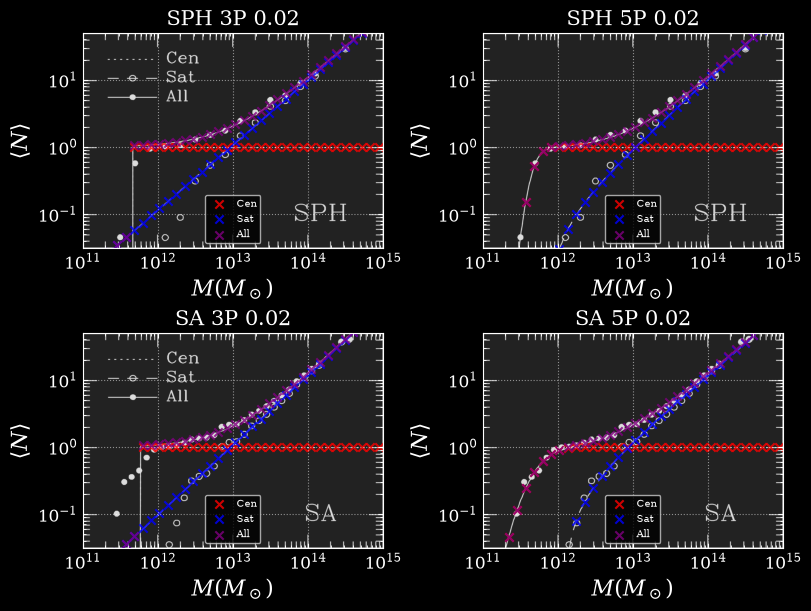

In [7]:
importlib.reload(Zheng2005)
fig, axs = Zheng2005.Fig3().full()

from Models import HODs
importlib.reload(HODs)

axs = axs.flatten()
logMh = np.linspace(10, 15.5, 50)

configs = [("SPH", "3P"),("SPH", "5P"),("SA",  "3P"),("SA",  "5P")]
for ax, (model, nparams) in zip(axs, configs):
    Z05 = HODs.Zheng2005(model=model, nparams=nparams, ng="0.02")
    ax.set_title(f"{model} {nparams} 0.02", size=15)
    ax.scatter(10**logMh, Z05.Ncen(logMh)(), marker="x", c="red", alpha=0.8, label="Cen")
    ax.scatter(10**logMh, Z05.Nsat(logMh)(), marker="x", c="blue", alpha=0.8, label="Sat")
    ax.scatter(10**logMh, Z05.Ntot(logMh)(), marker="x", c="purple", alpha=0.8, label="All")
    ax.legend(loc="lower center", fontsize=7)

plt.show()